# Construcción y análisis de redes semánticas asistido por IA
Usaremos el lenguaje de programación `python` ya que es mucho más fácil invocar y manipular modelos de IA.

El pipeline de este tutorial es el siguiente:
1. Dedicaremos 30 min a repasar los básicos de python
2. Construcción de red semántica
   1. Leeremos los datos de texto usando `pandas` 
   2. Invocaremos al modelo de embeddings `'all-MiniLM-L6-v2'` usando `sentence_transformers`
   3. Calcularemos embeddings de los datos de texto
   4. Calcularemos la matriz de similaridad entre embeddings
   5. Usaremos k-vecinos para establecer las aristas de la red
   6. Construiremos la red usando `networkx`
3. Análisis de red semántica con `networkx`
   1. Visualizaremos la red
   2. Inferiremos comunidades usando métodos que maximizan modularidad
   3. Calcularemos la centralidad de grado e identificaremos los nodos más centrales
   4. Exploraremos cualitativamente los textos asociados al análisis
   5. Experimentaremos con hacer *queries* al texto. 

In [ ]:
# Setup inicial. Ejecutar antes que nada para tener los datos y las librerías disponibles.
!git clone https://github.com/blas-ko/microcredencial_redes_2026.git
%pip install pandas numpy networkx sentence_transformers

In [1]:
# Importamos librerías
import pandas as pd # bases de datos
import numpy as np # operaciones algebraicas
import networkx as nx # redes
from sentence_transformers import SentenceTransformer # modelos de embedding

## Básicos de python
Antes de hablar de python, hablemos de *Google Colab*. Google Colab funciona como un **notebook**, donde hay *bloques*. Un bloque puede ser de código o de texto (agrega con `+ Código` o `+ Texto` respectivamente). Para ejecutar un bloque de código, puedes presionar el botón de Play o `Shift + Enter`.

En `python`, veremos operaciones muy básicas pero ojalá que sean las suficientes para ir siguiendo el tutorial. El resultado de una operación aparece debajo del bloque.

En el código, siempre podemos agregar comentarios con `#`, lo cual no afecta el código para nada.

In [2]:
# Primer comentario: podemos hacer operaciones básicas como una calculadora
5 + 8

13

In [3]:
# Podemos asignar valores a una variable con el nombre que queramos
x = 8
henry = 2
x + henry

10

Existen variables de distintos **tipos**:

In [4]:
# números enteros
3

3

In [5]:
# números flotantes (con punto decimal)
2.1

2.1

In [6]:
# texto (strings), que se indica dentro de "" o ''
"esto es un texto"

'esto es un texto'

In [7]:
'esto también'

'esto también'

In [8]:
# algunos tipos pueden operar juntos
3 + 2.1 

5.1

In [9]:
# otros no, y marca error
3 + 'tres'

TypeError: unsupported operand type(s) for +: 'int' and 'str'

El error te dará una pista de qué está saliendo mal. En este caso, dice que no existe la operación `+` entre enteros (`int`) y texto (`str`)

Un tipo de variable muy común son los **iterables**. Estos incluyen **listas**, **tuplas**, y **diccionarios**.

En general, sus elementos pueden ser de cualqueir tipo, no solo números

In [10]:
# lista 
[1, 3, 4, 7]

[1, 3, 4, 7]

In [11]:
# lista equivalente
[
    1,
    3,
    4,
    7
]

[1, 3, 4, 7]

In [12]:
# tupla 
('a', 'bola', 'mar')

('a', 'bola', 'mar')

In [13]:
# diccionario (requiere dos valores: llave y valor)
{
    'edad_juan': 25,
    'edad_pedro': 18,
    'edad_maria': 33,
}

{'edad_juan': 25, 'edad_pedro': 18, 'edad_maria': 33}

In [14]:
# Podemos acceder a los elementos de una lista (el primer elemento es el 0)
x = ["Hugo", "Paco", "Luisa"]
x[0] # primer elemento

'Hugo'

Así como en `R`, también existen **funciones**. 

Hay dos tipos de funciones:
- **función externa**: parecido a R, tiene sintaxis `f(x)`, con `x` el input y `f` la función
- **método**: son funciones heredadas de alguna variable, tienen sintaxis `x.f()`, indicando que la variable `x` contiene al método `f`.

In [15]:
# definamos una variable de texto
s = 'una prueba'

In [16]:
# ejemplo de función externa
len(s) # cuenta el número de caracteres de s

10

In [17]:
# ejemplo de método
s.capitalize() # capitaliza la primera letra del texto

'Una prueba'

Algunas funciones pueden tener comportamientos distintos dependiendo del tipo del input.

In [18]:
# veamos qué hace la función len con nuestra lista x
len(x)

3

Algunas funciones externas muy comunes:
- `print`: imprime lo que se le ponga como input
- `range`: genera un iterable de números (una lista, vamos) dentro de un rango

In [19]:
# la función print es muy útil para imprimir mensajes en cualquier momento
print(3)

3


In [20]:
# la sintaxis f nos permite combinar texto con variables
a = 5
print(f"el valor de a es {a}") # f antes de las "", el valor de la variables dentro de {}

el valor de a es 5


In [21]:
# incluso podemos hacer operaciones dentro del {}
print(f"el valor de a es {a+10}")
print(f"el valor de la operación es {20+10-14}")

el valor de a es 15
el valor de la operación es 16


También podemos definir nuestras propias funciones usando `def`.

La sintaxis es de la forma
```python
def nombre_de_la_funcion(inputs):
    # código
    return outputs
```

In [22]:
# hagamos una función que eleve un número al cuadrado
def cuadrado(x):
    x_cuadrado = x * x
    return x_cuadrado

In [23]:
# ahora podemos llamar a nuestra función
cuadrado(4)

16

In [24]:
# las funciones pueden tener los inputs que queramos, e incluso definir valores por defecto
def cuadrado_de_multiplicacion(x, y, z=2): # si no pongo un tercer valor, lo toma como 2 por defecto
    multip = x * y * z
    multip_cuadrado = cuadrado(multip)
    return multip_cuadrado

In [25]:
# debería dar 36: 2*1.5*2 = 6; 6*6=36
cuadrado_de_multiplicacion(2, 1.5)

36.0

En python, es muy común hacer **bucles** que recorren los elementos de un iterable.

La sintaxis es 
```python
for elemento in lista:
    # operación con elemento
```

También se puede hacer de manera más compacta como

`[ f(elemento) for elemento in lista ]`

donde `f` es la operación que queramos hacer con cada elemento de la lista.

In [26]:
# Imprimamos cada nombre en la lista
nombres = ["Hugo", "Paco", "Luisa"]
for nombre in nombres:
    print(f"El nombre es: {nombre}")

El nombre es: Hugo
El nombre es: Paco
El nombre es: Luisa


In [27]:
# enumerate es una función que te da el número de elemento de una lista
nombres = ["Hugo", "Paco", "Luisa"]
for i, nombre in enumerate(nombres):
    print(f"{i}. El nombre es: {nombre}")

0. El nombre es: Hugo
1. El nombre es: Paco
2. El nombre es: Luisa


Las **librerías** son funciones y pedazos de código especializadas hechas por la comunidad. 

Por ejemplo, la librería `numpy` hace operaciones con matrices, vectores y otras movidas algebraicas.

Uno puede cargar la librería completa con la sintaxis:
- `import numpy as np`
- Esto quiere decir: importa la libería `numpy` y llama a sus métodos usando el prefijo `np`

In [31]:
import numpy as np # esto ya estaba arriba

# hagamos una lista de números
numeros = [10, 23, 30]

# saquemos el promedio usando los métodos especializados de numpy
np.mean(numeros)

np.float64(21.0)

In [32]:
# también podemos cargar métodos específicos
from numpy import median

# así, no necesitamos llamar a np
median(numeros)

np.float64(23.0)

## Construcción de red semántica
Ahora sí, vamos a la construcción de la red semántica. Usaremos los métodos especializados de:
- `pandas` para leer y manipular los datos de texto (prefijo `pd`)
- `sentence_transformer` para invocar al modelo de embedding y sacar las similaridades semánticas (método `SentenceTransformer`)
- `numpy` para calcular las aristas de los k-vecinos a partir de la matriz de similaridades (prefijo `np`)
- `networkx` para construir y analizar la red a partir de las aristas (prefijo `nx`)

In [33]:
# Leemos el dataset de texto de noticias
# path_data = 'microcredencial_redes_2026/data/news_data.csv'
path_data = 'data/news_data.csv'
data = pd.read_csv(path_data)
data

,text
0,(marketscreener.com) Strong growth in monthly ...
1,The attraction closures take place just before...
2,UNILEVER Philippines is planning to expand its...
3,Wealthspire Advisors LLC bought a new stake in...
4,The ASX is primed to open up 0.6 per cent and ...
...,...
604,(marketscreener.com) L3Harris is pleased to an...
605,"Regulatory News: AFYREN (Paris:ALAFY), a green..."
606,BETA Technologies prototype ALIA CTOL battery-...
607,With airlines expecting this to be the busiest...


In [34]:
# Cargmos el modelo de embeddings desde Hugging-Face: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
# Generamos embeddings para cada texto, donde el embedding es un vector de tamaño 384
## OBS: Si tenemos 609 textos, esto resultará en una matrix de 609 filas y 384 columnas
embeddings = model.encode( data['text'] )
embeddings.shape

(609, 384)

In [36]:
# Calculamos la similaridad entre cada par de textos
similarities = model.similarity(embeddings, embeddings)
similarities.fill_diagonal_(0) # Llenamos la diagonal de 0s, no nos interesa la auto-similaridad
similarities.shape

torch.Size([609, 609])

In [37]:
# Creamos una función para calcular las aristas de los k-vecinos más cercanos
def create_knn_edges(similarities, k=5):
    """Genera las aristas de los k-vecinos más cercanos de la matriz de similaridad."""
    # Empieza con una lista vacía
    edges = []
    
    # para el embedding de cada texto i , registra los k embeddings con mayor similaridad a i
    for i, sims_i in enumerate(similarities):
        
        # ordena los indices de similaridad del texto i del menos al más similar
        sorted_ids = np.argsort(similarities[i])
        # quédate con los k más similares
        k_most_similar = sorted_ids[-k:]
    
        # registra las aristas
        for j in k_most_similar:
            edges.append( (i, int(j)) )

    return edges

Número de nodos: 609
Número de aristas: 2247


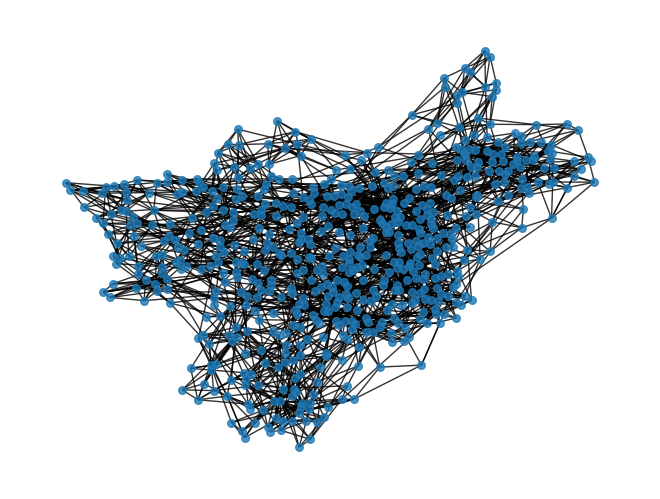

In [38]:
### CONSTRUCCIÓN DE RED SEMANTICA ###
# Genera las aristas de los k-vecinos de los embeddings
edges = create_knn_edges(similarities, k=5)

# Construye la red usando networkX
G = nx.from_edgelist( edges )
print("Número de nodos:", nx.number_of_nodes(G) )
print("Número de aristas:", nx.number_of_edges(G) )

# Visualiza la red
pos = nx.spring_layout(G, seed=42) # calculamos posiciones de los nodos
nx.draw(G, pos, node_size=30, alpha=0.8)

## Análisis de red semántica

Numero de comunidades: 12


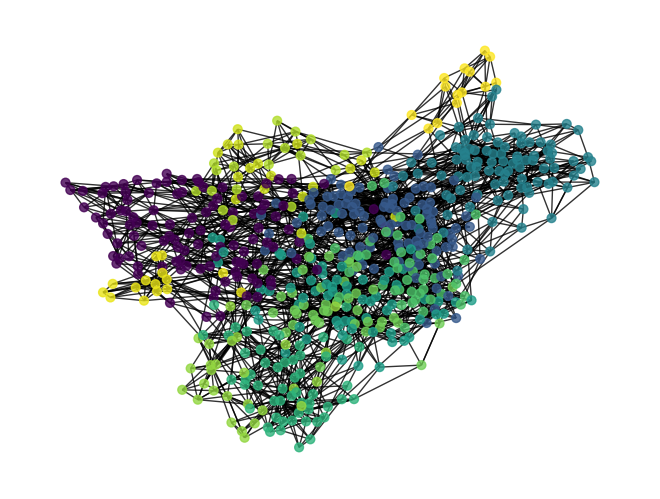

In [39]:
# Ahora, vamos a ver si existen comunidades de noticias usando el método de maximización de modularidad
C = nx.community.louvain_communities(G)

# Limpiamos las comunidades: 1) ordenamos de más a menos grandes, 2) creamos un diccionario nodo:comunidad
C = sorted(C, key=len, reverse=True)
C_dict = {node: i for i, comm in enumerate(C) for node in comm}
# Le asignamos a cada nodo un color distinto
colors = [ np.log(C_dict[n] + 1) for n in G.nodes()]
print(f"Numero de comunidades: {len(C)}")

# Visualizamos comunidades
nx.draw(G, pos, node_size=40, alpha=0.8, node_color=colors)

In [40]:
# Generamos una función para ver el texto dentro de una comunidad dada
def print_texts_in_community(data, community, max_texts=5):
    texts_in_community = data.loc[list(community),'text']
    
    n_texts = min(max_texts, len(texts_in_community))
    for i in range(n_texts):
        text = texts_in_community.iloc[i]
        print( f"TEXT: {text}", end="\n\n" )

In [41]:
# Veamos algunos de los textos dentro de comunidades
community = C[0]
print_texts_in_community(data, community, max_texts=10)

TEXT: Once an aspiring Olympian, Landon Driggers wants everyone to know he's more than his sport.

TEXT: The attraction closures take place just before the Halloween crowds descend on the Disney parks.

TEXT: It seems that EA is looking to make EA Sports FC 24 even more expensive, with a new paid season pass as well as loot boxes.

TEXT: Terrell Owens thinks Tom Brady disrespected him about three years ago, and the Hall of Fame wide receiver is still not over it. In a recent appearance on the &#8220;Bubba Dub Show,&#8221; Owens claimed he had reached out to Brady in 2021, after Antonio Brown famously walked out on the Tampa Bay Buccaneers on the...The post Terrell Owens claims to have been disrespected by Tom Brady appeared first on Larry Brown Sports.

TEXT: Jake Paul first tiptoed into a boxing ring in 2018 in a celebrity boxing fight. He has come a long way since then and proved that he is here to stay. The 27-year-old has brought new eyes to the sport, leading to increased revenue.

In [42]:
# Calculamos la centralidad de grado usando networkx
centralities = nx.centrality.degree_centrality(G)
centralities = pd.Series(centralities)

# Extraemos los nodos de mayor y menor centralidad
most_central = centralities.nlargest(5).index
least_central = centralities.nsmallest(5).index

print("###### TEXTOS CON MAYOR CENTRALIDAD DGRADO ######\n")
print_texts_in_community(data, most_central)

print("###### TEXTOS CON MENOR CENTRALIDAD DGRADO ######\n")
print_texts_in_community(data, least_central)


###### TEXTOS CON MAYOR CENTRALIDAD DGRADO ######

TEXT: (marketscreener.com) NEW YORK, July 11, 2024 /PRNewswire/ --&nbsp;Monteverde &amp; Associates PC , has recovered money for shareholders and is recognized as a Top 50&nbsp;Firm in the 2018-2022 ISS Securities Class Action Services Report. We are headquartered at the&nbsp;Empire State Building&nbsp;in New York City and are investigating Strong Global Entertainment,...https://www.marketscreener.com/quote/stock/STRONG-GLOBAL-ENTERTAINME-154226644/news/The-M-A-Class-Action-Firm-Investigates-Merger-of-Strong-Global-Entertainment-Inc-SGE-47366714/?utm_medium=RSS&utm_content=20240711

TEXT: (marketscreener.com) July 16, 2024 Company Name: Universal Entertainment Corporation ...https://www.marketscreener.com/quote/stock/UNIVERSAL-ENTERTAINMENT-C-6814877/news/Universal-Entertainment-Notice-Concerning-Establishment-of-Record-Date-for-Convocation-of-Extraord-47388819/?utm_medium=RSS&utm_content=20240716

TEXT: (marketscreener.com) FOCUS ENTE

In [43]:
# También podemos hacer queries y ver a qué embedding se parece más.
query_emb = model.encode("Query: music and korea")
most_similar = np.argmax(model.similarity(query_emb, embeddings))
data.loc[int(most_similar),'text']

'K-pop girl group Unis is making a comeback in August. According to F&F Entertainment, Unis is introducing its new single &ldquo;Curious&rdquo; on Aug. 6. Unis is a K-pop girl group comprising eight finalists from the SBS audition program &ldquo;Universe Ticket&rdquo; that debuted with its first mini album &ldquo;We Unis&rdquo; in March. The album sold more than 55,000 copies just within five days of its release. Unis recently won the Asia Star Award at the 2024 Korea Best Brand Awards held i'